In [41]:
import tensorflow as tf
import keras
import numpy as np
import matplotlib.pyplot as plt
import kagglehub as kh
import os
import pandas as pd
from keras import Model
from helper import *
from sklearn.preprocessing import MinMaxScaler
from helper import *
from keras.layers import LSTM, Dense, RepeatVector, TimeDistributed, Input, BatchNormalization, Input, Attention, Concatenate
from scipy.stats import spearmanr

%matplotlib inline

In [42]:
training = True

In [43]:
tf.random.set_seed(42)
path = kh.dataset_download("palbha/cmapss-jet-engine-simulated-data")

col_names = ['Unit', 'Cycle Time', 'Op1', 'Op2', 'Op3'] + [f'Sensor {_+1}' for _ in range(23)]
df = pd.read_csv(os.path.join(path, 'train_FD001.txt'), sep=' ', header=None, names=col_names)
df_test = pd.read_csv(os.path.join(path, 'test_FD001.txt'), sep=' ', header=None, names=col_names)

In [44]:
cols_to_drop = ['Sensor 1', 'Sensor 5', 'Sensor 6', 'Sensor 10', 'Sensor 16', 'Sensor 17', 'Sensor 18', 'Sensor 19', 'Sensor 22', 'Sensor 23']
relevant_sensors = [f'Sensor {_+1}' for _ in range(23) if _ not in (0, 4, 5, 9, 15, 16, 17, 18, 21, 22)]
ops = ['Op1', 'Op2']
df = df.drop(columns=cols_to_drop)
df_test = df_test.drop(columns=cols_to_drop)
df.head() # Check added col names

,Unit,Cycle Time,Op1,Op2,Op3,Sensor 2,Sensor 3,Sensor 4,Sensor 7,Sensor 8,Sensor 9,Sensor 11,Sensor 12,Sensor 13,Sensor 14,Sensor 15,Sensor 20,Sensor 21
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,38.90,23.4044


In [45]:
# ~~~~~~~~~~~~~~
# Pre-process data
# ~~~~~~~~~~~~~~
wsize = 10

# Fit ONLY on the first 50 cycles of the training data 
# This defines the 0.0 to 1.0 range based on HEALTHY engines
scaler = MinMaxScaler()
scaler.fit(df.groupby('Unit').head(wsize)[ops + relevant_sensors])

# Transform everything using that "Healthy Range"
df[ops + relevant_sensors] = scaler.transform(df[ops + relevant_sensors])
df_test[ops + relevant_sensors] = scaler.transform(df_test[ops + relevant_sensors])

In [46]:
X_train, Y_train = gen_train_windows_multi(df, wsize, ops, relevant_sensors)
X_test, Y_test, test_units = gen_test_windows_multi(df_test, wsize, ops, relevant_sensors)

# Double check data shapes
print(X_train.shape) # Should have more inputs (Operation settings)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(4100, 10, 15)
(4100, 10, 13)
(100, 10, 15)
(100, 10, 13)


In [47]:
# Define dimensions based on your lists
n_inputs = len(ops) + len(relevant_sensors) # Total features in X_train
n_targets = len(relevant_sensors)            # Only the sensors in Y_train

In [48]:
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense, Attention, Concatenate, Reshape, Multiply, GlobalAveragePooling1D
from tensorflow.keras.models import Model
import tensorflow.keras as keras

# ==========================================
# 1. DEFINE THE LAYERS
# ==========================================
inputs = Input(shape=(wsize, n_inputs))

# --- NEW: FEATURE ATTENTION BLOCK ---
# 1. Compress time to get a summary of each sensor's activity
avg_pool = GlobalAveragePooling1D()(inputs) 

# 2. Learn a weight (0 to 1) for each sensor using Softmax
# These are your "Feature Importance" scores
feature_weights = Dense(n_inputs, activation='softmax', name='feature_weights')(avg_pool)

# 3. Reshape and multiply against the original input
# This "highlights" the important sensors and "mutes" the noise
feature_weights_reshaped = Reshape((1, n_inputs))(feature_weights)
weighted_inputs = Multiply()([inputs, feature_weights_reshaped])
# ------------------------------------

# 2. Encoder (Now using the weighted_inputs)
encoder_out, state_h, state_c = LSTM(64, activation='tanh', return_sequences=True, return_state=True)(weighted_inputs)

# 3. Bottleneck & Decoder
bottleneck = RepeatVector(wsize)(state_h)
decoder_out = LSTM(64, activation='tanh', return_sequences=True)(bottleneck)

# 4. Temporal Attention
attention_results = Attention()([decoder_out, encoder_out], return_attention_scores=True)
context_vector = attention_results[0]
temporal_attention_scores = attention_results[1]

# 5. Combine & Output
combined_features = Concatenate(axis=-1)([decoder_out, context_vector])
outputs = TimeDistributed(Dense(n_targets), name="sensor_predictions")(combined_features)

# ==========================================
# 2. CREATE MODELS
# ==========================================
# Training Model: Only needs the sensor predictions
train_model = Model(inputs=inputs, outputs=outputs, name="training_model")
train_model.compile(optimizer='adam', loss='mae')

# Inference Model: Outputs predictions, Temporal weights, AND Feature weights
inference_model = Model(
    inputs=inputs, 
    outputs=[outputs, temporal_attention_scores, feature_weights], 
    name="inference_model"
)

# ==========================================
# 3. TRAIN & PREDICT
# ==========================================
# (Training code remains identical to your previous snippet)
history = train_model.fit(X_train, Y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Now predict returns 3 items
results = inference_model.predict(X_test)
predictions = results[0]
temp_weights = results[1]  # Heatmap data (Time)
feat_weights = results[2]  # Bar chart data (Sensors)

Epoch 1/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1898 - val_loss: 0.1177
Epoch 2/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0992 - val_loss: 0.0956
Epoch 3/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0937 - val_loss: 0.0918
Epoch 4/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0897 - val_loss: 0.0893
Epoch 5/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0889 - val_loss: 0.0891
Epoch 6/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0887 - val_loss: 0.0890
Epoch 7/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0886 - val_loss: 0.0889
Epoch 8/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0885 - val_loss: 0.0888
Epoch 9/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0884 - val_loss: 0.0888
Epoch 10/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0883 - val_loss: 0.0886
Epoch 11/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0883 - val_loss: 0.0886
Epoch 12/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

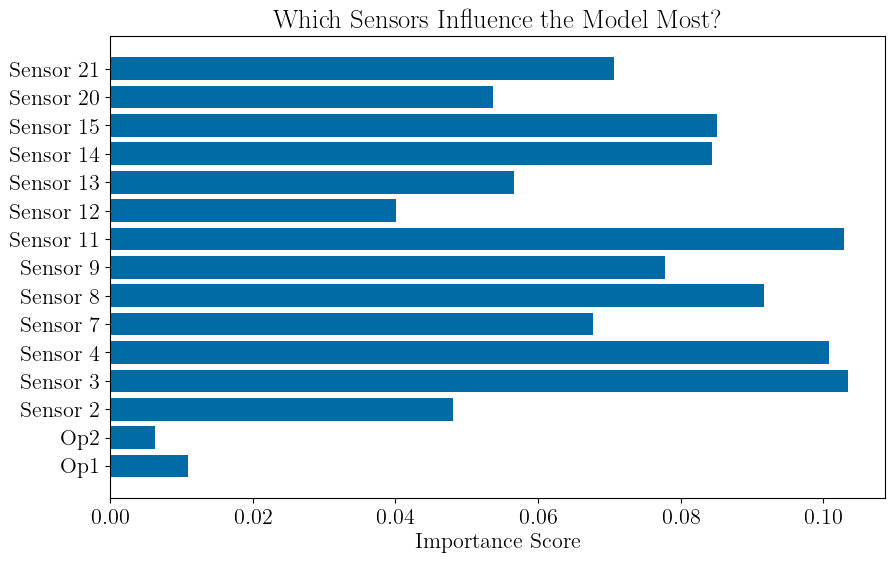

In [49]:
import matplotlib.pyplot as plt

# names = ['sensor1', 'sensor2', 'op_setting1', ...]
avg_feat_importance = feat_weights.mean(axis=0)

names = ["Op1", "Op2"] + relevant_sensors

plt.figure(figsize=(10, 6))
plt.barh(names, avg_feat_importance)
plt.title("Which Sensors Influence the Model Most?")
plt.xlabel("Importance Score")
plt.show()

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


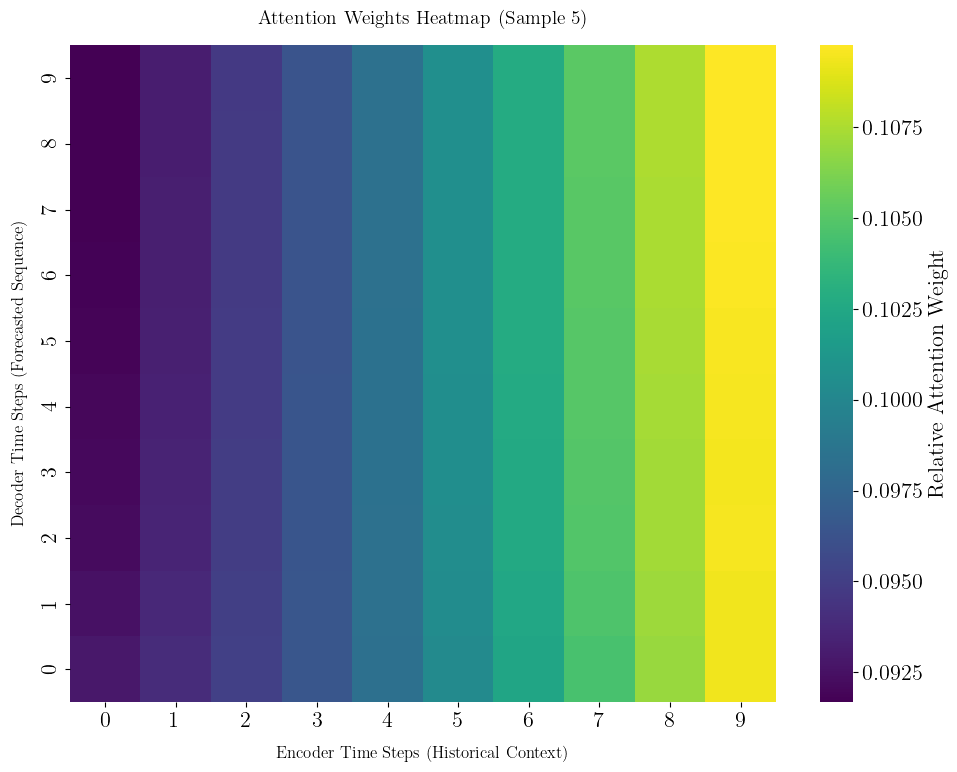

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_attention_heatmap(inference_model, x_data, sample_idx=0):
    """
    Generates predictions and plots the attention heatmap for a specific sample.
    """
    # 1. Run inference to get predictions and attention weights
    # inference_model outputs: [predictions (batch, wsize, targets), weights (batch, wsize, wsize)]
    results = inference_model.predict(x_data)
    all_attention_weights = results[1]
    
    # 2. Extract the 2D attention matrix for the requested sample
    attention_matrix = all_attention_weights[sample_idx]
    
    # 3. Set up the plot
    plt.figure(figsize=(10, 8))
    
    # Draw the heatmap
    # 'viridis' or 'magma' are excellent colormaps for highlighting focus areas
    # Change this part of your plotting function:
    ax = sns.heatmap(
        attention_matrix, 
        cmap="viridis",
        # vmin=0.0,  <-- DELETE THIS
        # vmax=1.0,  <-- DELETE THIS
        cbar_kws={'label': 'Relative Attention Weight'}
    )
    
    # 4. Configure labels
    plt.title(f"Attention Weights Heatmap (Sample {sample_idx})", fontsize=14, pad=15)
    plt.xlabel("Encoder Time Steps (Historical Context)", fontsize=12, labelpad=10)
    plt.ylabel("Decoder Time Steps (Forecasted Sequence)", fontsize=12, labelpad=10)
    
    # Invert the Y-axis so time step 0 is at the top left
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.show()

# ==========================================
# Example Usage
# ==========================================
# Assuming X_test is your sliding window test data
# Let's visualize the very first sequence in your test set
plot_attention_heatmap(inference_model, X_train, sample_idx=5)

In [51]:
# n_inputs = len(ops) + len(relevant_sensors)
# n_targets = len(relevant_sensors)

# 1. Input Layer
inputs = Input(shape=(wsize, n_inputs))

# 2. Encoder
# CHANGED: return_sequences=True outputs the hidden state for EVERY time step (for Attention).
# ADDED: return_state=True grabs the final hidden state separately (for the Bottleneck).
encoder_out, state_h, state_c = LSTM(64, activation='tanh', return_sequences=True, return_state=True)(inputs)

# 3. Bottleneck
# We repeat the final hidden state (state_h) to kick off the decoding process
bottleneck = RepeatVector(wsize)(state_h)

# 4. Decoder
# Processes the repeated state to generate the base target sequence
decoder_out = LSTM(64, activation='tanh', return_sequences=True)(bottleneck)

# 5. Attention Layer (NEW)
# The core of the upgrade. 
# Query: The Decoder's current state (what it's trying to predict right now)
# Value: The Encoder's full history (all the past context it can draw from)
# attention_results = Attention()([decoder_out, encoder_out], return_attention_scores = True)

context_vector, attention_weights = Attention()([decoder_out, encoder_out], return_attention_scores = True)

print(context_vector.shape)
print(attention_weights.shape)

# Combine the Decoder's baseline sequence with the highly-focused Attention context
combined_features = Concatenate(axis=-1)([decoder_out, context_vector])

# 6. Output Layer
# Maps the rich, attention-aware features down to your specific sensor targets
outputs = TimeDistributed(Dense(n_targets), name="sensor_predictions")(combined_features)

# Create the Model object
# model = Model(inputs=inputs, outputs=[outputs], name="lstm_attention_autoencoder")
weight_extractor = Model(inputs=inputs, outputs=[attention_weights], name="lstm_attention_autoencoder_attention_weights")
model = Model(inputs=inputs, outputs=[outputs], name="lstm_attention_autoencoder")

# Compile
model.compile(optimizer='adam', loss='mae')
model.summary()

# Compile attention part
weight_extractor.compile(optimizer='adam', loss='mae')
weight_extractor.summary()

(None, 10, 64)
(None, 10, 10)


Model: "lstm_attention_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 10, 15)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_14 (LSTM)      │ [(None, 10, 64),  │     20,480 │ input_layer_7[0]… │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_7     │ (None, 10, 64)    │          0 │ lstm_14[0][1]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_15 (LSTM)      │ (None, 10, 64)    │     33,024 │ repeat_vector_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_7         │ [(None, 10, 64),  │          0 │ lstm_15[0][0],    │
│ (Attention)         │ (None, 10, 10)]   │            │ lstm_14[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 10, 128)   │          0 │ lstm_15[0][0],    │
│ (Concatenate)       │                   │            │ attention_7[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_predictions  │ (None, 10, 13)    │      1,677 │ concatenate_7[0]… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 55,181 (215.55 KB)

 Trainable params: 55,181 (215.55 KB)

...

Model: "lstm_attention_autoencoder_attention_weights"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 10, 15)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_14 (LSTM)      │ [(None, 10, 64),  │     20,480 │ input_layer_7[0]… │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_7     │ (None, 10, 64)    │          0 │ lstm_14[0][1]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_15 (LSTM)      │ (None, 10, 64)    │     33,024 │ repeat_vector_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_7         │ [(None, 10, 64),  │          0 │ lstm_15[0][0],    │
│ (Attention)         │ (None, 10, 10)]   │            │ lstm_14[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 53,504 (209.00 KB)

 Trainable params: 53,504 (209.00 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=5),
             keras.callbacks.ModelCheckpoint(filepath='best_model_fd001.keras', monitor='val_loss', save_best_only=True)]

if training:
    history = model.fit(
        X_train, Y_train, 
        epochs=50, 
        batch_size=32, 
        validation_split=0.1, 
        verbose=1,
        callbacks=callbacks
    )

Epoch 1/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1278 - val_loss: 0.0899
Epoch 2/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0886 - val_loss: 0.0884
Epoch 3/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0878 - val_loss: 0.0877
Epoch 4/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0872 - val_loss: 0.0872
Epoch 5/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0866 - val_loss: 0.0867
Epoch 6/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0860 - val_loss: 0.0868
Epoch 7/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0855 - val_loss: 0.0863
Epoch 8/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0851 - val_loss: 0.0855
Epoch 9/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0847 - val_loss: 0.0854
Epoch 10/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0845 - val_loss: 0.0849
Epoch 11/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0842 - val_loss: 0.0846
Epoch 12/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

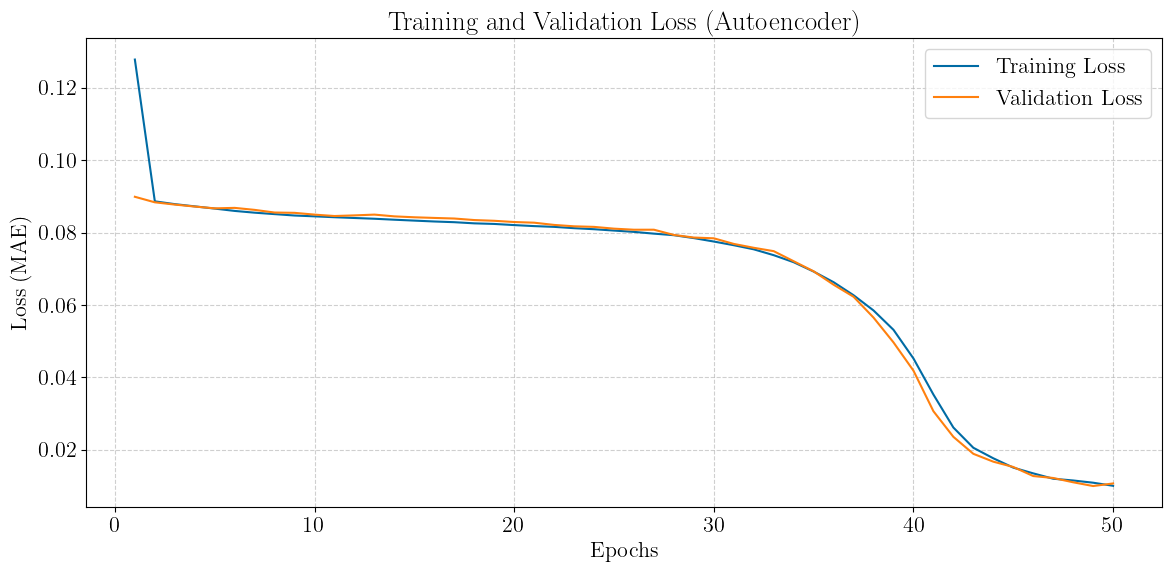

In [53]:
if training:
    fig = make_loss_plot(history)
    plt.show()

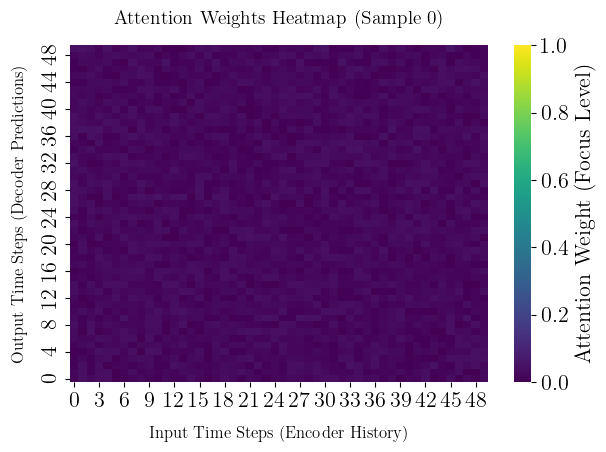

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_attention_heatmap(attention_matrix, sample_index=0):
    """
    Plots a heatmap of attention weights for a single time-series sample.
    
    Args:
        attention_matrix: A 2D numpy array of shape (decoder_steps, encoder_steps).
        sample_index: Just a label for the plot title to know which sample this is.
    """
    # Set up the matplotlib figure
    # plt.figure(figsize=(10, 8))
    
    # Draw the heatmap using seaborn
    # cmap="viridis" is great for visual perception, mapping low values to dark purple 
    # and high values to bright yellow.
    ax = sns.heatmap(
        attention_matrix, 
        cmap="viridis",
        vmin=0.0, 
        vmax=1.0, # Attention weights always sum to 1.0 across the encoder steps
        cbar_kws={'label': 'Attention Weight (Focus Level)'}
    )
    
    # Configure labels and title
    plt.title(f"Attention Weights Heatmap (Sample {sample_index})", fontsize=14, pad=15)
    plt.xlabel("Input Time Steps (Encoder History)", fontsize=12, labelpad=10)
    plt.ylabel("Output Time Steps (Decoder Predictions)", fontsize=12, labelpad=10)
    
    # Optional: Invert the Y-axis so time step 0 is at the top left
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.show()

# ==========================================
# Example Usage
# ==========================================
if __name__ == "__main__":
    # Assume `X_test` is your input data of shape (batch_size, wsize, n_inputs)
    # predictions, all_attention_weights = model.predict(X_test)
    
    # For this example, let's mock the weights for a single sequence with a window size of 50
    # (Shape: 50 decoder steps x 50 encoder steps)
    wsize = 50
    mock_weights = np.random.rand(wsize, wsize)
    
    # Normalize the mock data so each row sums to 1.0 (just like real attention)
    mock_weights = mock_weights / mock_weights.sum(axis=1, keepdims=True)
    
    # We grab the very first sample in our test batch (index 0)
    sample_to_plot = mock_weights
    
    plot_attention_heatmap(sample_to_plot, sample_index=0)

### 04

In [55]:
col_names = ['Unit', 'Cycle Time', 'Op1', 'Op2', 'Op3'] + [f'Sensor {_+1}' for _ in range(23)]
df = pd.read_csv(os.path.join(path, 'train_FD004.txt'), sep=' ', header=None, names=col_names)
df_test = pd.read_csv(os.path.join(path, 'test_FD004.txt'), sep=' ', header=None, names=col_names)

In [56]:
# Using to_string with specific formatting
with open('data_summary_FD004.txt', 'w') as f:
    f.write("CMAPSS Dataset Summary Statistics\n")
    f.write("="*30 + "\n")
    f.write(df.describe().transpose().to_string()) # Transpose makes it easier to read if you have many sensors

In [57]:
cols_to_drop = ['Sensor 22', 'Sensor 23']
relevant_sensors = [f'Sensor {_+1}' for _ in range(20)]
ops = ['Op1', 'Op2', 'Op3']
df = df.drop(columns=cols_to_drop)
df_test = df_test.drop(columns=cols_to_drop)
df.head()

,Unit,Cycle Time,Op1,Op2,Op3,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,...,Sensor 12,Sensor 13,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 21
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754


In [58]:
df[relevant_sensors] = df[relevant_sensors].astype('float64')
df_test[relevant_sensors] = df_test[relevant_sensors].astype('float64')

In [59]:
cols_to_drop = ['Sensor 13', 'Sensor 16', 'Sensor 19']
df = df.drop(columns=cols_to_drop)
df_test = df_test.drop(columns=cols_to_drop)

In [60]:
relevant_sensors.remove('Sensor 13')
relevant_sensors.remove('Sensor 16')
relevant_sensors.remove('Sensor 19')

In [61]:
# 1. Add a 'Regime' column to your data (this is a common FD004 trick)
# This rounds the Op settings to identify the 6 discrete clusters
df['Regime'] = df[ops].round(1).astype(str).sum(axis=1)
df_test['Regime'] = df_test[ops].round(1).astype(str).sum(axis=1)

# 2. Scale each sensor per regime
for s in relevant_sensors:
    for regime in df['Regime'].unique():
        mask = (df['Regime'] == regime)
        test_mask = (df_test['Regime'] == regime)
        
        # Fit ONLY on healthy starts of training data for this regime
        regime_healthy = df[mask].groupby('Unit').head(30)[s]
        m, std = regime_healthy.mean(), regime_healthy.std()
        
        # Transform Train and Test (Standardize)
        df.loc[mask, s] = (df.loc[mask, s] - m) / (std + 1e-9)
        df_test.loc[test_mask, s] = (df_test.loc[test_mask, s] - m) / (std + 1e-9)

In [62]:
ops_scaler = MinMaxScaler()
df[ops] = ops_scaler.fit_transform(df[ops])
df_test[ops] = ops_scaler.transform(df_test[ops])

In [63]:
X_train, Y_train = gen_train_windows_fd004(df, wsize, ops, relevant_sensors)
X_test, Y_test = gen_test_windows_fd004(df_test, wsize, ops, relevant_sensors)

In [64]:
n_in = X_train.shape[2]  # 16
n_out = Y_train.shape[2] # 13

# Architecture
inputs = Input(shape=(wsize, n_in))

# Encoder
# Using tanh is often more stable for standardized data (Z-score)
encoder = LSTM(64, activation='tanh', return_sequences=False)(inputs)

# Bottleneck
bottleneck = RepeatVector(wsize)(encoder)

# Decoder
decoder = LSTM(64, activation='tanh', return_sequences=True)(bottleneck)

# Output: Reconstruct only the 13 health sensors
outputs = TimeDistributed(Dense(n_out))(decoder)

model = keras.models.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='mae')

callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=5),
             keras.callbacks.ModelCheckpoint(filepath='best_model_fd004.keras', monitor='val_loss', save_best_only=True)]

# Train
history = model.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks
)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - loss: 0.5407 - val_loss: 0.5497
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.4778 - val_loss: 0.4902
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.4330 - val_loss: 0.4479
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.4057 - val_loss: 0.4218
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.3903 - val_loss: 0.4063
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.3807 - val_loss: 0.3934
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.3725 - val_loss: 0.3852
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.3668 - val_loss: 0.3783
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.3626 - val_loss: 0.3740
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.3599 - val_loss: 0.3709
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.3579 - val_loss: 0.3681
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.3561 - val_loss: 0.3660
